In [1]:
import sys
sys.path.append("../src")

import numpy as np
from astropy import constants as const
from astropy import units as u

from augment import Sampler, format_summary_table


sampler = Sampler(n_samples=100_000, seed=42)

sampler.add(
    "temperature",
    5772 * u.K,
    upper_error=80 * u.K,
    lower_error=60 * u.K,
    lower=0 * u.K,
)

sampler.add(
    "radius",
    1.0 * u.solRad,
    upper_error=0.08 * u.solRad,
    lower_error=0.05 * u.solRad,
    lower=0 * u.solRad,
)


def stefan_boltzmann(temperature, radius):
    flux = const.sigma_sb * temperature**4
    luminosity = 4 * np.pi * radius**2 * flux

    return {
        "flux": flux.to(u.W / u.m**2),
        "luminosity": luminosity.to(u.W),
    }


out = sampler.run(
    stefan_boltzmann,
    return_samples=True,
    error_budget_against="luminosity",
)

print(format_summary_table(
    out,
    keys=("luminosity", "flux"),
    tablefmt="plain",
))

Parameter       Value  +Error/-Error          Unit  
----------  ---------  ---------------------  ------
luminosity  3.878e+26  +6.406e+25/-4.413e+25  W     
flux        6.292e+07  +3.560e+06/-2.551e+06  W / m2


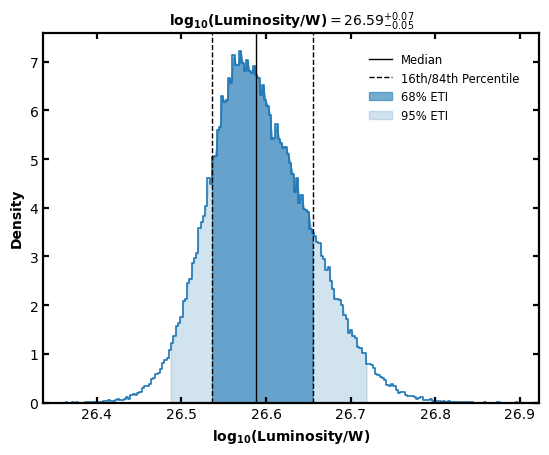

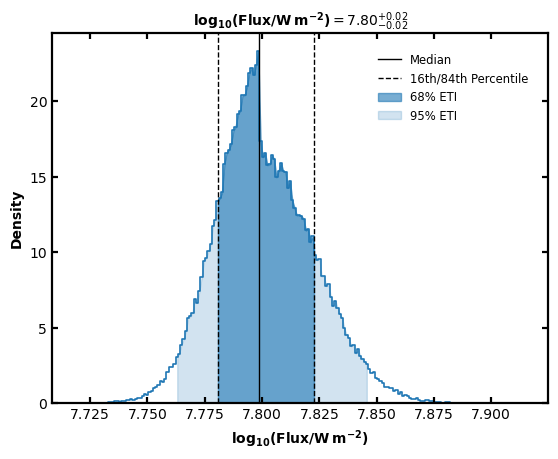

In [2]:
import matplotlib.pyplot as plt

from augment import plot_ecdf, plot_posterior


fig, ax = plt.subplots()
plot_posterior(
    out,
    key="luminosity",
    log10=True,
    ax=ax,
    pretty_label=r"Luminosity",
)

fig, ax = plt.subplots()
plot_posterior(
    out,
    key="flux",
    log10=True,
    ax=ax,
    pretty_label=r"Flux",
)

plt.show()

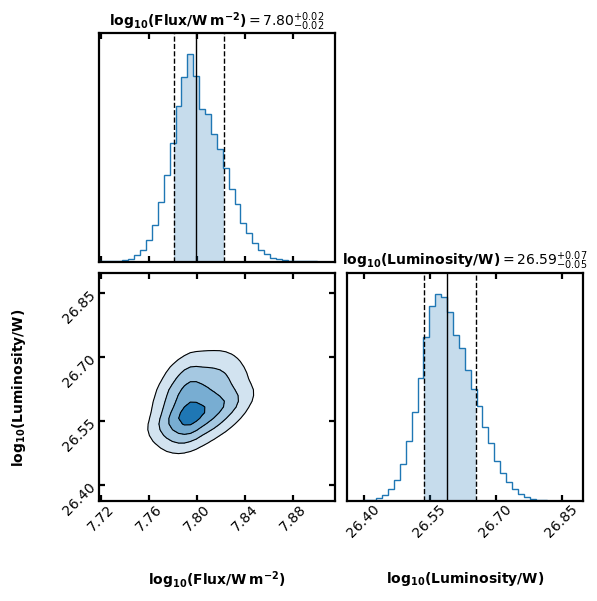

In [7]:
from augment import plot_corner


fig = plot_corner(
    out,
    keys=("flux", "luminosity"),
    log_keys=("flux", "luminosity"),
    label_map={
        "flux": r"Flux",
        "luminosity": r"Luminosity",
    },
)